In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors  import NearestNeighbors
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.datasets import make_moons, make_circles, load_wine

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(42)

print('Импорты выполнены успешно!')

Импорты выполнены успешно!


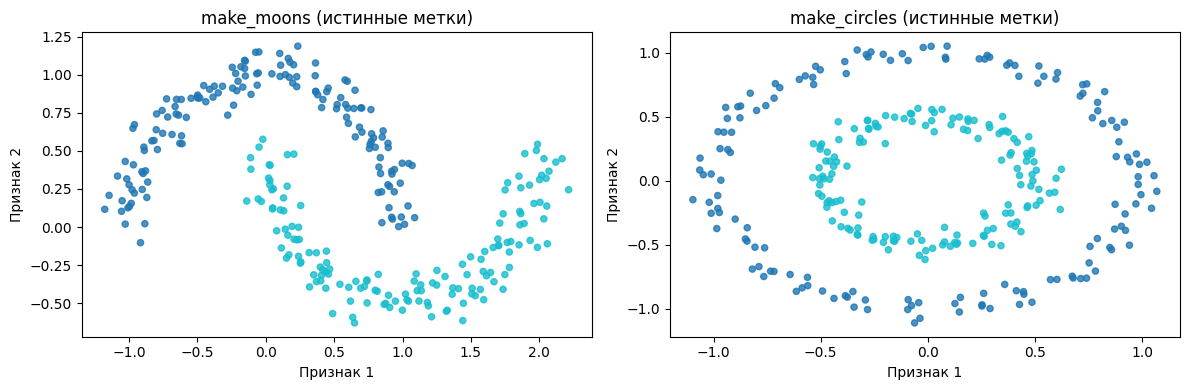

In [3]:
# Генерация датасета

X_moon, y_moon = make_moons(n_samples= 300, noise= 0.08, random_state= RANDOM_STATE)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor= 0.5, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c = y_moon, cmap = 'tab10', alpha = 0.8, s = 20)
axes[0].set_title("make_moons (истинные метки)")
axes[0].set_xlabel("Признак 1")
axes[0].set_ylabel("Признак 2")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("make_circles (истинные метки)")
axes[1].set_xlabel("Признак 1")
axes[1].set_ylabel("Признак 2")

plt.tight_layout()
plt.show()

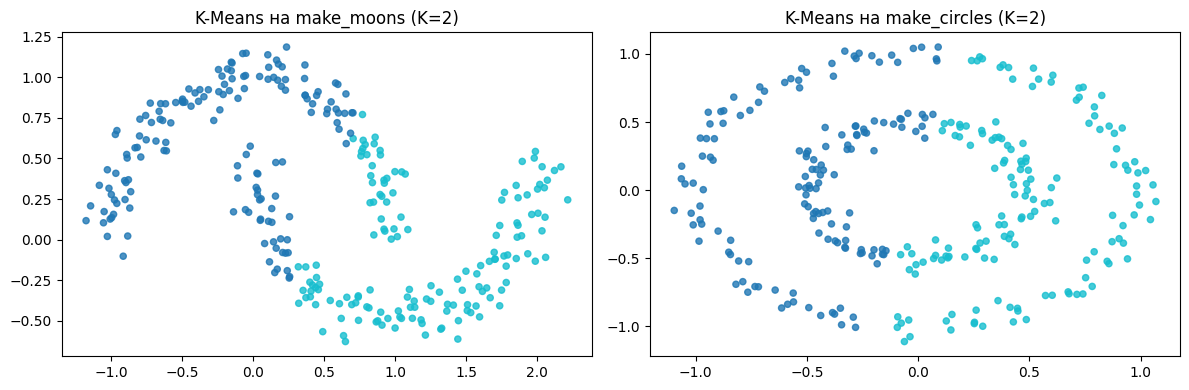

In [4]:
# Применение K-means к созданным датасетам

kmeans_moons = KMeans(n_clusters= 2, random_state= RANDOM_STATE)
labels_km_moons = kmeans_moons.fit_predict(X_moon)

kmeans_circles = KMeans(n_clusters= 2, random_state= RANDOM_STATE)
labels_km_circles = kmeans_circles.fit_predict(X_circles)

fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes[0].scatter(X_moon[:, 0], X_moon[:, 1], c = labels_km_moons, cmap = 'tab10', s=20, alpha = 0.8)
axes[0].set_title("K-Means на make_moons (K=2)")

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=labels_km_circles, cmap='tab10', s=20, alpha=0.8)
axes[1].set_title("K-Means на make_circles (K=2)")

plt.tight_layout()
plt.show()

Ограниченность алгоритма K-Means в задачах со сложной топологией обусловлена минимизацией внутрикластерной суммы квадратов отклонений. Данный функционал ошибки неявно предполагает, что данные распределены изотропно, что диктует сферическую форму и выпуклость итоговых кластеров. Математически это приводит к формированию линейных границ (ячеек Вороного), которые не способны аппроксимировать нелинейно разделимые и вогнутые структуры, такие как «луны» или вложенные контуры

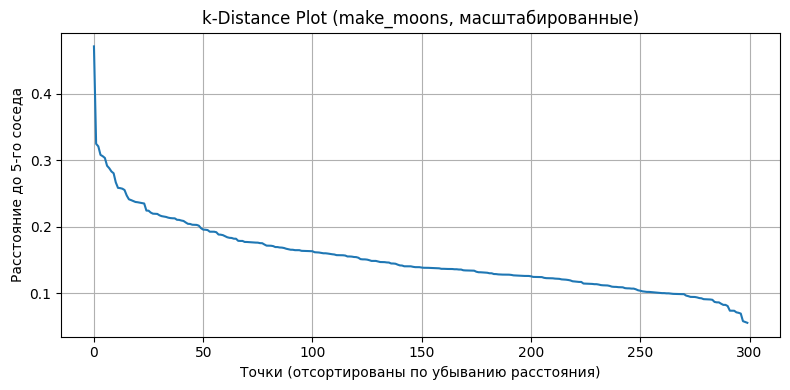

In [5]:
# Применение DBSCAN

scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moon)

k = 5

nn = NearestNeighbors(n_neighbors= k)
nn.fit(X_moons_scaled)

distances, inidices = nn.kneighbors(X_moons_scaled)

k_distances_moons = np.sort(distances[:, k-1])[: : -1]

plt.figure(figsize=(8, 4))
plt.plot(k_distances_moons)
plt.xlabel("Точки (отсортированы по убыванию расстояния)")
plt.ylabel(f"Расстояние до {k}-го соседа")
plt.title("k-Distance Plot (make_moons, масштабированные)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Исходя из графика eps = 0.32
Все точки слева от изгиба - шум, так как у них даже ближайшие соседи находятся слишком далеко, поэтому график там такой высокий. Все точки справа являются кластерами: они сидят плотно, поэтому расстояние до соседей у них маленькое и график уходит в пологую линию. Выбирая eps на уровне этого изгиба, мы задаем модели правильный радиус так, что он достаточно мал, чтобы не захватить лишний мусор, но достаточно велик, чтобы связать все точки внутри одной 'луны' в единую группу.

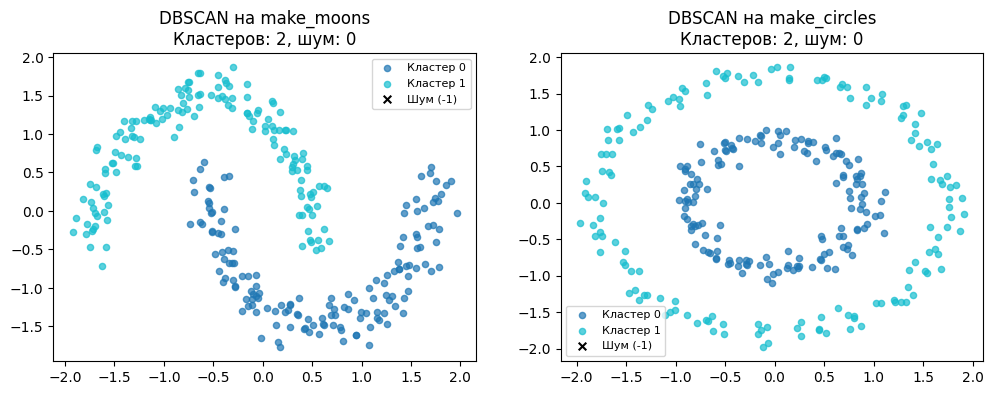

In [6]:
# DBSCAN на нелинейных датасетах

scaler_circled = StandardScaler()
X_circles_scaled = scaler_circled.fit_transform(X_circles)


db_moons = DBSCAN(eps= 0.32, min_samples = 5)
label_db_moons = db_moons.fit_predict(X_moons_scaled)

db_cirles = DBSCAN(eps= 0.32, min_samples = 5)
label_db_circles = db_cirles.fit_predict(X_circles_scaled)

def plot_dbscan_result(X, labels, title, ax):
    """Визуализирует результаты DBSCAN.
    Корневые точки — крупные, граничные — обычные, шум — крестики."""
    
    noise_mask = labels == -1
    colors = cm.tab10(np.linspace(0, 1, max(labels)+1)) if max(labels) >= 0 else []

    for i in range(max(labels)+1):
        mask = labels == i
        ax.scatter(X[mask, 0], X[mask, 1], s=20, alpha=0.7,
                   color=colors[i], label=f'Кластер {i}')
    
    ax.scatter(X[noise_mask, 0], X[noise_mask, 1],
               s=30, c='black', marker='x', label='Шум (-1)')
    
    n_cl = max(labels) + 1 if max(labels) >= 0 else 0
    n_noise = noise_mask.sum()
    ax.set_title(f"{title}\nКластеров: {n_cl}, шум: {n_noise}")
    ax.legend(fontsize=8)


fig, axes = plt.subplots(1, 2, figsize = (12, 4))

plot_dbscan_result(X_moons_scaled, label_db_moons, 'DBSCAN на make_moons', axes[0])
plot_dbscan_result(X_circles_scaled, label_db_circles, 'DBSCAN на make_circles', axes[1])






In [7]:
# Сравнение DBSCAN и K-Means на нелинейных данных

score_kmeans = silhouette_score(X_moon, labels_km_moons)

score_dbscan = silhouette_score(X_moons_scaled, label_db_moons)

print("=== Коэффициент силуэта на make_moons ===")
print(f"K-Means (K=2): {score_kmeans:.3f}" if score_kmeans is not None else "K-Means: не вычислен")
print(f"DBSCAN:        {score_dbscan:.3f}" if score_dbscan is not None else "DBSCAN: не вычислен")

=== Коэффициент силуэта на make_moons ===
K-Means (K=2): 0.484
DBSCAN:        0.380


Лучший результат по коэффициенту силуэта показал алгоритм K-Means, набрав примерно 0,484 против 0,380 у DBSCAN. С чисто математической точки зрения это означает, что K-Means создал более компактные и четко разделенные группы точек. Однако этот численный перевес является обманчивым и совершенно не отражает реальное качество сегментации данных в данном эксперименте.
Визуальный анализ демонстрирует парадокс: K-Means совершил грубую ошибку, разрезав целостные 'луны' пополам, в то время как DBSCAN безупречно восстановил их истинную форму. Разница в оценках возникла из-за того, что формула силуэта поощряет округлые структуры и штрафует вытянутые кластеры за большую дистанцию между их противоположными краями. Для K-Means, создавшего компактные, но неверные шары, средние расстояния оказались меньше, что и привело к незаслуженно высокому баллу.
В итоге можно сделать вывод, что коэффициенту силуэта нельзя доверять как абсолютной мере качества, особенно в задачах с нелинейной геометрией. Эта метрика обладает сферическим смещением, из-за чего она всегда будет отдавать предпочтение округлым формам, игнорируя сложную топологию данных. При работе с изогнутыми или вытянутыми кластерами необходимо сочетать силуэт с визуализацией.

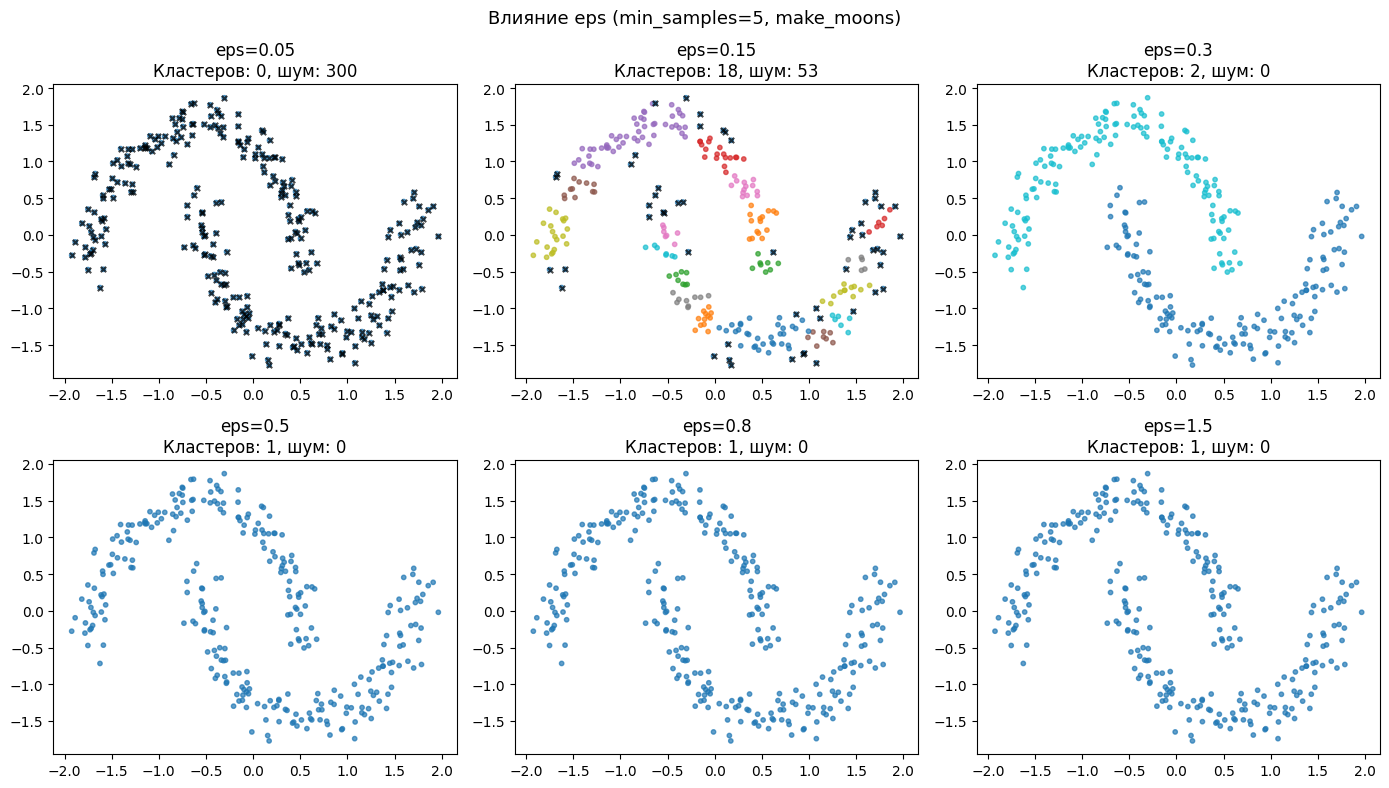

In [8]:
# Исследование влияния eps

eps_values =  [0.05, 0.15, 0.3, 0.5, 0.8, 1.5]
fig, axes = plt.subplots(2, 3, figsize =(14, 8))
axes = axes.flatten()

for i, eps_val in enumerate(eps_values):
    model = DBSCAN(eps= eps_val, min_samples= 5)
    labels_i = model.fit_predict(X_moons_scaled)
    
    n_cl = len(set(labels_i)) - (1 if -1 in labels_i else 0)
    n_noise = (labels_i == -1).sum()

    axes[i].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                        c=labels_i, cmap='tab10', s=10, alpha=0.7)
    axes[i].scatter(X_moons_scaled[labels_i == -1, 0], X_moons_scaled[labels_i == -1, 1], c = 'black', marker = 'x', s=15, alpha = 0.7)
    axes[i].set_title(f"eps={eps_val}\nКластеров: {n_cl}, шум: {n_noise}")

plt.suptitle("Влияние eps (min_samples=5, make_moons)", fontsize=13)
plt.tight_layout()
plt.show()
    




Оптимальным оказалось значение eps=0.3, так как именно при нем алгоритм четко выделил две луны, не раздробив их на части. При слишком маленьком eps (0.05 или 0.15) точки находятся слишком далеко друг от друга для объединения, поэтому всё превращается в мусор из мелких групп и шума. А при слишком большом значении (0.5 и выше) радиус поиска становится таким широким, что алгоритм перестает видеть пустоту между объектами и ошибочно склеивает две разные фигуры в одну общую массу.

In [15]:
# DBSCAN на реальном датасете Wine

wine = load_wine()
print(wine.keys())
X_wine = wine.data
y_wine = wine.target
feature_names = wine.feature_names

print(f"Форма данных: {X_wine.shape}")
print(f"Признаки: {feature_names}")
print(f"\nСтатистика признаков:")
df_wine = pd.DataFrame(X_wine, columns=feature_names)
print(df_wine.describe().round(2))

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names'])
Форма данных: (178, 13)
Признаки: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']

Статистика признаков:
       alcohol  malic_acid     ash  alcalinity_of_ash  magnesium  \
count   178.00      178.00  178.00             178.00     178.00   
mean     13.00        2.34    2.37              19.49      99.74   
std       0.81        1.12    0.27               3.34      14.28   
min      11.03        0.74    1.36              10.60      70.00   
25%      12.36        1.60    2.21              17.20      88.00   
50%      13.05        1.87    2.36              19.50      98.00   
75%      13.68        3.08    2.56              21.50     107.00   
max      14.83        5.80    3.23              30.00     162.00   

       total_phenols  flavanoids  nonfl

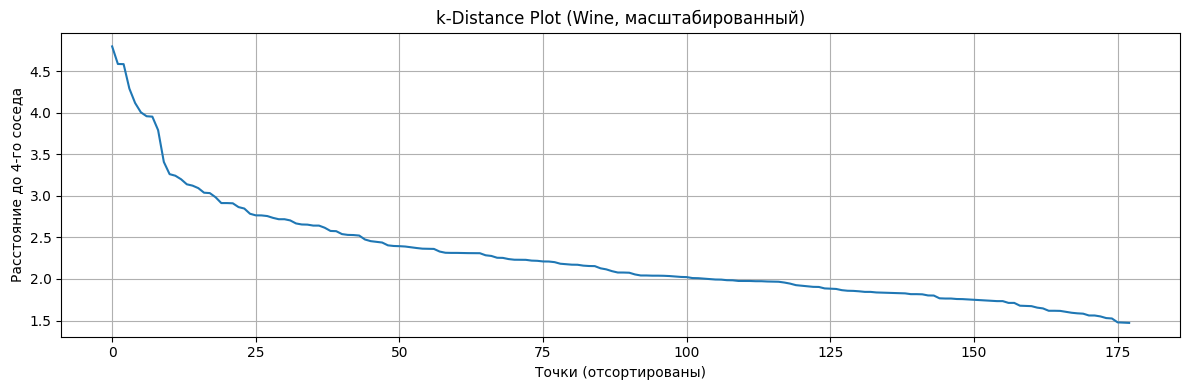

In [23]:
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)
k_wine = 4

nn_wine = NearestNeighbors(n_neighbors= k_wine)
nn_wine.fit(X_wine_scaled)
distances, inidices = nn_wine.kneighbors(X_wine_scaled)
k_dist_wine = np.sort(distances[:, k_wine-1])[: : -1]

plt.figure(figsize=(12, 4))
plt.plot(k_dist_wine)
plt.xlabel("Точки (отсортированы)")
plt.ylabel(f"Расстояние до {k_wine}-го соседа")
plt.title("k-Distance Plot (Wine, масштабированный)")
plt.grid(True)
plt.tight_layout()
plt.show()

EPS = 2.1

In [45]:
eps_wine = 2.1

db_wine = DBSCAN(eps= eps_wine, min_samples= 4)
labels_wine =  db_wine.fit_predict(X_wine_scaled)

n_cl_wine = len(set(labels_wine)) - (1 if -1 in labels_wine else 0)
n_noise_wine = (labels_wine == -1).sum()
noise_ratio = n_noise_wine / len(labels_wine)

print("=== Результаты DBSCAN на Wine ===")
print(f"Число кластеров: {n_cl_wine}")
print(f"Число шумовых точек: {n_noise_wine}")
print(f"Доля шума: {noise_ratio:.2%}")

if n_cl_wine > 1:
    wine_mask = labels_wine != -1
    score_wine = silhouette_score(X_wine_scaled[wine_mask], labels_wine[wine_mask])
    print(f'Силуэт (без шума): {score_wine:.3f}')
else:
    print('Силуэт: нужно минимум 2 кластера')


=== Результаты DBSCAN на Wine ===
Число кластеров: 3
Число шумовых точек: 57
Доля шума: 32.02%
Силуэт (без шума): 0.211


In [55]:
# Анализ шумовых точек

X_wine_noise = X_wine[labels_wine != -1]

df_wine_noise = pd.DataFrame(X_wine_noise, columns= feature_names)

mean_total = df_wine.mean()
mean_noise = df_wine_noise.mean()

comparison = pd.DataFrame({
    'Total Mean': mean_total,
    'Noise Mean': mean_noise,
    'Difference (%)': ((mean_noise - mean_total) / mean_total) * 100
})

display(comparison.sort_values('Difference (%)', ascending= False, key=lambda x: x.abs()))

,Total Mean,Noise Mean,Difference (%)
proline,746.893258,794.727273,6.404398
color_intensity,5.058090,5.345702,5.686190
malic_acid,2.336348,2.237769,-4.219393
proanthocyanins,1.590899,1.532975,-3.640940
alcalinity_of_ash,19.494944,19.214876,-1.436618
nonflavanoid_phenols,0.361854,0.356860,-1.380233
od280/od315_of_diluted_wines,2.611685,2.645455,1.293002
alcohol,13.000618,13.123636,0.946250
total_phenols,2.295112,2.273636,-0.935727
hue,0.957449,0.949504,-0.829841


Самые заметные отличия: Proline (+6.4%), Color Intensity (+5.6%), Malic_acid(-4.2%)
В данном случае шумовые точки не являются «плохими» данными или грубыми ошибками измерений, т.к. их ключевые показатели (уровень алкоголя или пролина) отклоняются от средних значений всего на 1–6%. Скорее всего это реальные объекты, которые просто обладают нетипичным сочетанием характеристик или расположены в разреженных зонах между основными сортами вина, из-за чего DBSCAN не может плотно привязать их ни к одной из устойчивых групп. Поэтому это не аномалии, а пограничные случаи, которые подчеркивают естественную неоднородность и сложность структуры данных.

Силуэт K-Means: 0.285
Силуэт DBSCAN: 0.211


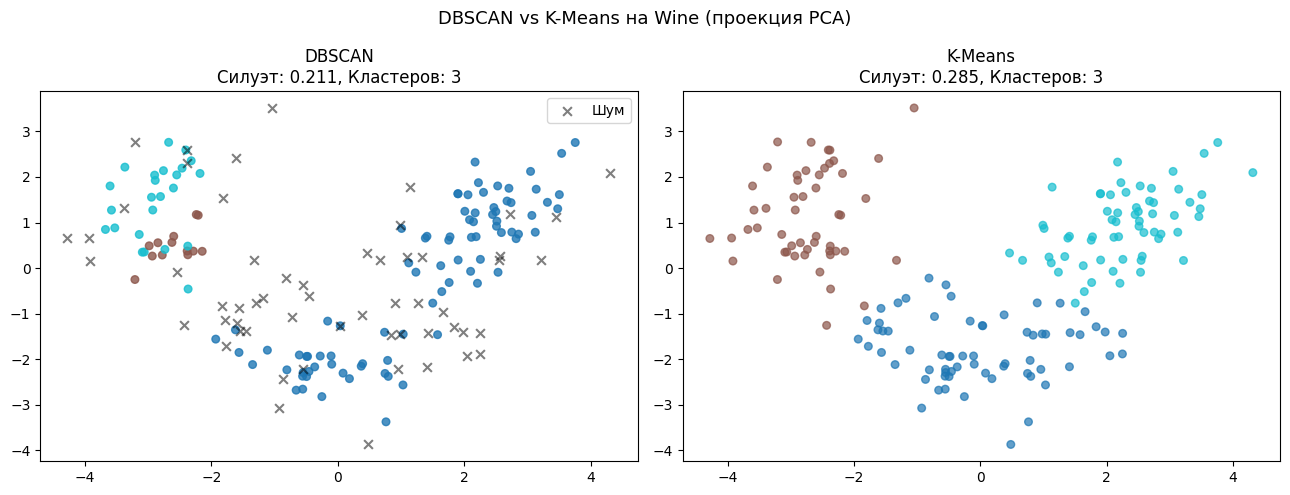

In [69]:
# Итоговое сравнение: DBSCAN vs K-Means на Wine

from sklearn.decomposition import PCA

pca = PCA(n_components= 2, random_state= RANDOM_STATE)
X_wine_2d = pca.fit_transform(X_wine_scaled)

kmeans_wine = KMeans(n_clusters= 3, random_state= RANDOM_STATE)
labels_km_wine = kmeans_wine.fit_predict(X_wine_scaled)

score_km_wine = silhouette_score(X_wine_scaled, label_km_wine)

print(f"Силуэт K-Means: {score_km_wine:.3f}")
print(f"Силуэт DBSCAN: {score_wine:.3f}")


fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(X_wine_2d[labels_wine != -1, 0], X_wine_2d[labels_wine != -1, 1], c = labels_wine[labels_wine != -1], 
                cmap = 'tab10', s = 30, alpha = 0.8)
axes[0].scatter(X_wine_2d[labels_wine == -1, 0], X_wine_2d[labels_wine == -1, 1], c = 'black', marker = 'x', s=40, alpha = 0.5,
                label = 'Шум')
axes[0].set_title(f"DBSCAN\nСилуэт: {score_wine:.3f}, Кластеров: {n_cl_wine}")
axes[0].legend()

axes[1].scatter(X_wine_2d[:, 0], X_wine_2d[:, 1], 
                c=labels_km_wine, cmap='tab10', s=30, alpha=0.7)
axes[1].set_title(f"K-Means\nСилуэт: {score_km_wine:.3f}, Кластеров: 3")

plt.suptitle("DBSCAN vs K-Means на Wine (проекция PCA)", fontsize=13)
plt.tight_layout()
plt.show()

# Итоговые выводы

**1. Когда DBSCAN выигрывает у K-Means?**

DBSCAN лучше справляется, когда данные имеют сложную, извилистую форму (как луны) или когда в данных много выбросов. В отличие от K-Means, он не обязан делить всё пространство на сектора и не пытается вписать кластеры в форму идеальных кругов/шаров.

**2. Когда K-Means предпочтительнее?**

K-Means эффективнее, когда данные распределены равномерно(сферическими кластерами) и имеют примерно одинаковую плотность. Также он незаменим, если нужно заранее задать конкретное количество групп и если данных очень много т.к. он работает быстрее.

**3. Почему масштабирование обязательно для DBSCAN?**

DBSCAN работает на основе радиуса. Если один признак измеряется в тысячах (как пролин), а другой в единицах (как алкоголь), то большой признак полностью подавит маленький, и алгоритм будет учитывать только его, игнорируя остальные важные данные.

**4. Как интерпретировать шумовые точки в датасете Wine?**

Шумовые точки здесь - это не обязательно ошибки, а скорее пограничные случаи. Это вина, которые по своим характеристикам оказались в разреженных зонах между основными сортами. Они «недостаточно типичны», чтобы алгоритм мог уверенно отнести их к какой-то плотной группе.

**5. Можно ли корректно сравнивать силуэт DBSCAN и K-Means напрямую? Почему?**

Напрямую сравнивать их не совсем корректно, потому что K-Means оценивает все точки, а для DBSCAN мы обычно считаем силуэт только по нешумовым точкам. Если у DBSCAN много шума, его силуэт может быть высоким (на оставшихся плотных ядрах), но это не значит, что он описал всю выборку лучше, чем K-Means.